#Lista 1

##Instruções

#### • Com exceção dos casos explicitamente indicados, os algoritmos e modelos devem ser implementados do início em qualquer linguagem de programação.

#### • Pacotes auxiliares (sklearn, matplotlib, etc) podem ser usados somente para facilitar a manipulação dos dados e criar gráficos.

#### • Para a avaliação do trabalho, recomenda-se o envio de arquivo Jupyter notebook com os códigos executados e os resultados visíveis nas células.

In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Adjust the path below if your file is in a different location within Google Drive
data_path_artificial1d = '/content/drive/MyDrive/Classroom/[CTE-IA] Aprendizado de Máquina Prof. César Lincoln Mattos/Lista1/ama_lista_01/artificial1d.csv'
data_path_breastcancer = '/content/drive/MyDrive/Classroom/[CTE-IA] Aprendizado de Máquina Prof. César Lincoln Mattos/Lista1/ama_lista_01/breastcancer.csv'
data_path_california = '/content/drive/MyDrive/Classroom/[CTE-IA] Aprendizado de Máquina Prof. César Lincoln Mattos/Lista1/ama_lista_01/california.csv'
data_path_vehicle = '/content/drive/MyDrive/Classroom/[CTE-IA] Aprendizado de Máquina Prof. César Lincoln Mattos/Lista1/ama_lista_01/vehicle.csv'

ds_artificial1d = pd.read_csv(data_path_artificial1d)

ds_breastcancer = pd.read_csv(data_path_breastcancer)

ds_california = pd.read_csv(data_path_california)

ds_vehicle = pd.read_csv(data_path_vehicle)

Mounted at /content/drive


In [ ]:
# ds_artificial1d.head()

# ds_breastcancer.head()

# ds_california.head()

# ds_vehicle.head()


# Questão 1

##### Considere o conjunto de dados disponível em artificial1d.csv organizado em duas colunas, x e y. Seja um modelo de regressão linear para yˆ = f(x).

###### a) Apresente os parâmetros do modelo e o MSE (erro quadrático médio) obtidos pelo algoritmo OLS (mínimos quadrados ordinários). Plote a reta resultante sobre os dados.

Parâmetros do modelo (intercepto, inclinação): 0.0896, 1.5133
MSE (Erro Quadrático Médio): 0.2077


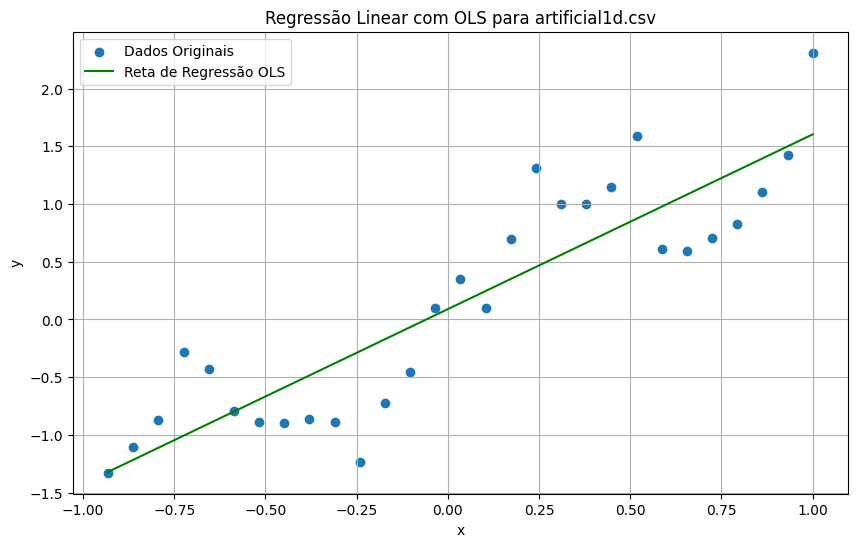

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Ajuste dos nomes das colunas
ds_artificial1d.columns = ['x', 'y']

# Preparar os dados para OLS
X = ds_artificial1d['x'].values
y = ds_artificial1d['y'].values

# Adicionar o termo de viés (intercepto) em X
X_b = np.c_[np.ones(X.shape[0]), X]

# Calcular os parâmetros do OLS (pesos)
w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Obter o intercepto e a inclinação
intercept = w[0]
slope = w[1]

# Fazer previsões
y_pred = X_b @ w

# Erro Quadrático Médio (MSE)
mse = np.mean((y_pred - y)**2)

print(f"Parâmetros do modelo (intercepto, inclinação): {intercept:.4f}, {slope:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")

# Gráfico regressão linear com OLS
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Dados Originais')
plt.plot(X, y_pred, color='green', label='Reta de Regressão OLS')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressão Linear com OLS para artificial1d.csv')
plt.legend()
plt.grid(True)
plt.show()


###### b) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem obtidos pelo algoritmo GD (gradiente descendente). Plote a reta resultante sobre os dados.

Parâmetros do modelo (intercepto, inclinação) com GD: 0.0897, 1.5114
MSE (Erro Quadrático Médio) com GD: 0.2077


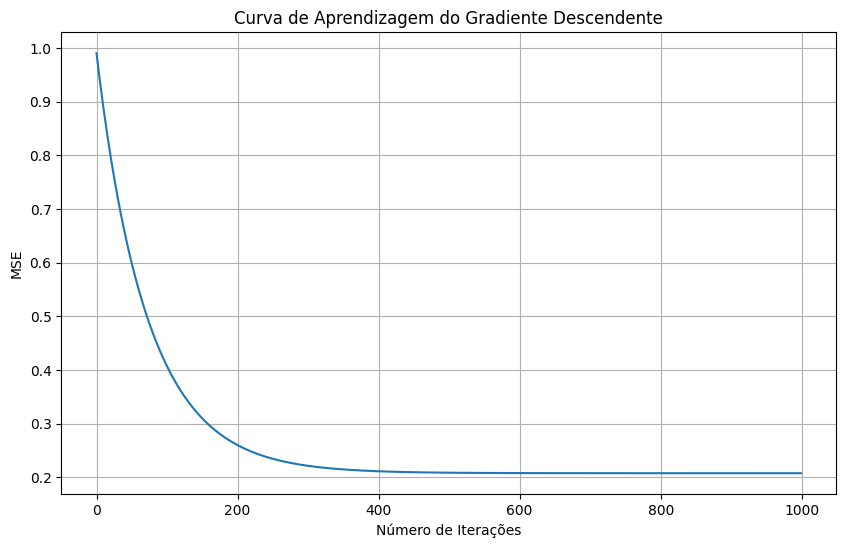

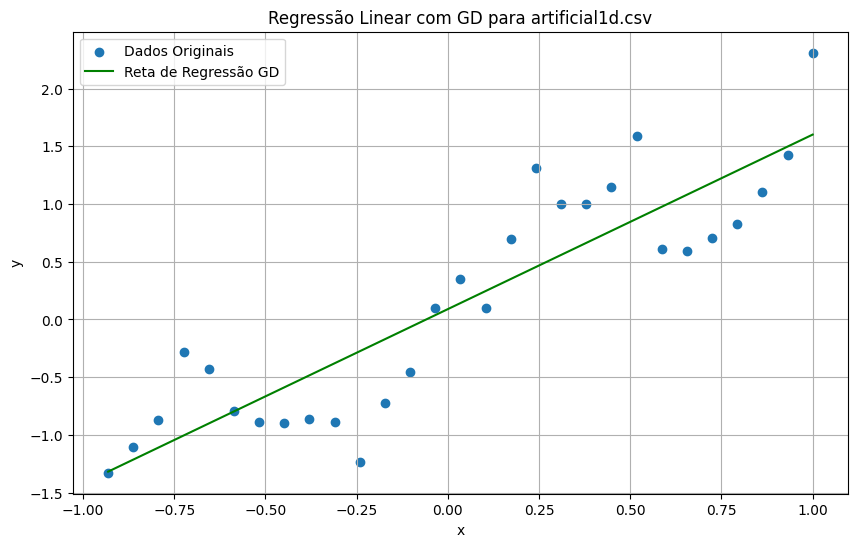

In [11]:
# Preparar os dados, adicionando um termo de viés (intercepto)
X = ds_artificial1d['x'].values
y = ds_artificial1d['y'].values
X_b = np.c_[np.ones(X.shape[0]), X]

# Parâmetros do gradiente descendente
learning_rate = 0.01
n_iterations = 1000

# Inicio dos pesos "theta" com zeros
theta = np.zeros(X_b.shape[1])

mse_history = []

# Algoritmo de gradiente descendente
for iteration in range(n_iterations):

    # Previsões
    y_pred = X_b @ theta

    # Erro
    errors = y_pred - y

    # Cálculo do gradiente da função de custo MSE
    gradients = (2/len(X_b)) * X_b.T @ errors

    # Atualização dos pesos
    theta = theta - learning_rate * gradients

    # Cálculo do MSE desta iteração e armazená-lo
    mse = np.mean(errors**2)
    mse_history.append(mse)

# Parâmetros finais
intercept_gd = theta[0]
slope_gd = theta[1]

# Previsões finais e MSE
y_pred_gd = X_b @ theta
mse_gd = np.mean((y_pred_gd - y)**2)

print(f"Parâmetros do modelo (intercepto, inclinação) com GD: {intercept_gd:.4f}, {slope_gd:.4f}")
print(f"MSE (Erro Quadrático Médio) com GD: {mse_gd:.4f}")

# Plotar a curva de aprendizagem (MSE ao longo das iterações)
plt.figure(figsize=(10, 6))
plt.plot(range(n_iterations), mse_history)
plt.xlabel('Número de Iterações')
plt.ylabel('MSE')
plt.title('Curva de Aprendizagem do Gradiente Descendente')
plt.grid(True)
plt.show()

# Plotar a reta de regressão sobre os dados
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Dados Originais')
plt.plot(X, y_pred_gd, color='green', label='Reta de Regressão GD')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressão Linear com GD para artificial1d.csv')
plt.legend()
plt.grid(True)
plt.show()


###### c) Apresente os parâmetros do modelo, o MSE e a curva de aprendizagem obtidos pelo algoritmo SGD (gradiente descendente estocástico). Plote a reta resultante sobre os dados.

Parâmetros do modelo (intercepto, inclinação) com SGD: 0.0870, 1.5127
MSE (Erro Quadrático Médio) com SGD: 0.2077


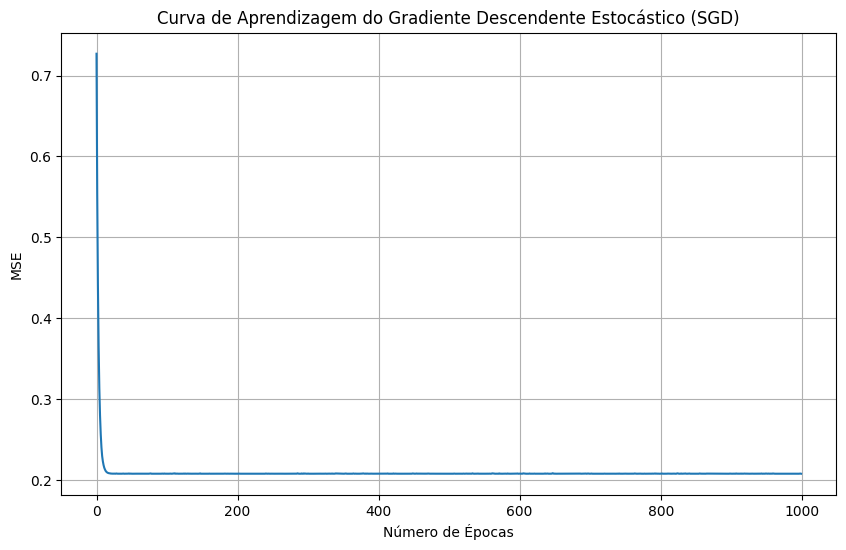

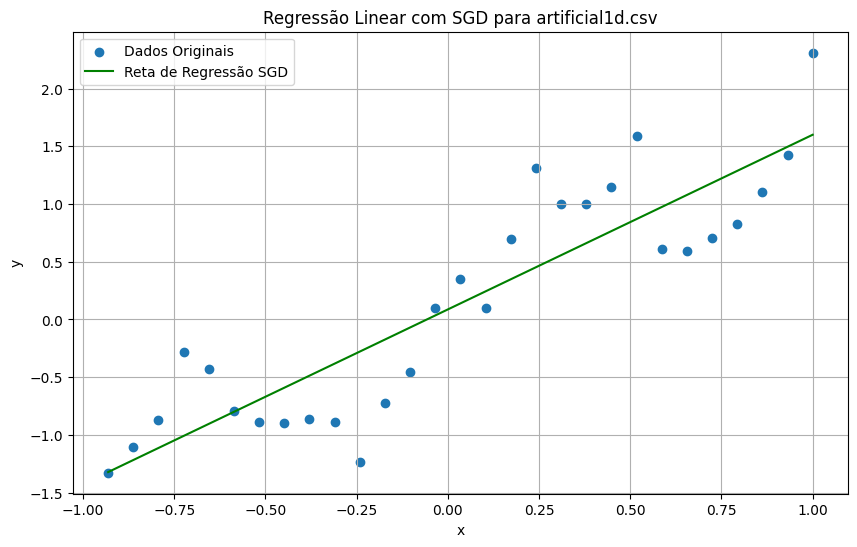

In [18]:
# Preparar os dados, adicionar o termo de viés (intercepto)
X = ds_artificial1d['x'].values
y = ds_artificial1d['y'].values
X_b = np.c_[np.ones(X.shape[0]), X]

# Parâmetros do SGD
learning_rate_sgd = 0.01
n_epochs = 1000
m = len(X_b)

# Início dos pesos (theta) aleatoriamente com zeros
theta_sgd = np.zeros(X_b.shape[1])
mse_history_sgd = []

# Algoritmo de gradiente descendente estocástico

for epoch in range(n_epochs):
    # Garantindo aleatoriedade
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]

    for i in range(m):
        # Selecionando uma instância aleatóriatmente(tamanho do lote = 1)
        xi = X_b_shuffled[i:i+1]
        yi = y_shuffled[i:i+1]

        # Cálculo da previsão da instância única
        y_pred_sgd_instance = xi @ theta_sgd

        # Cálculo do erro da instância única
        error_sgd_instance = y_pred_sgd_instance - yi

        # Cálculo do gradiente da instância única
        gradients_sgd = 2 * xi.T @ error_sgd_instance

        # Atualização dos pesos
        theta_sgd = theta_sgd - learning_rate_sgd * gradients_sgd

    # Cálculo do MSE para a curva de aprendizagem a cada época
    y_pred_epoch = X_b @ theta_sgd
    mse_epoch = np.mean((y_pred_epoch - y)**2)
    mse_history_sgd.append(mse_epoch)

# Parâmetros finais
intercept_sgd = theta_sgd[0]
slope_sgd = theta_sgd[1]

# Previsões finais e MSE
y_pred_sgd = X_b @ theta_sgd
mse_sgd = np.mean((y_pred_sgd - y)**2)

print(f"Parâmetros do modelo (intercepto, inclinação) com SGD: {intercept_sgd:.4f}, {slope_sgd:.4f}")
print(f"MSE (Erro Quadrático Médio) com SGD: {mse_sgd:.4f}")

# Curva de aprendizagem (MSE ao longo das épocas)
plt.figure(figsize=(10, 6))
plt.plot(range(n_epochs), mse_history_sgd)
plt.xlabel('Número de Épocas')
plt.ylabel('MSE')
plt.title('Curva de Aprendizagem do Gradiente Descendente Estocástico (SGD)')
plt.grid(True)
plt.show()

# Reta de regressão sobre os dados
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Dados Originais')
plt.plot(X, y_pred_sgd, color='green', label='Reta de Regressão SGD')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressão Linear com SGD para artificial1d.csv')
plt.legend()
plt.grid(True)
plt.show()


# Questão 2

##### Considere o conjunto de dados disponível em california.csv, organizado em 9 colunas, sendo as 8 primeiras colunas os atributos e a última coluna a saída.

##### Os 8 atributos são usados na predição da mediana de preços de casas em distritos da Califórnia na década de 1990. Maiores detalhes sobre os dados podem ser conferidos em https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset

###### a) Aleatoriamente, divida o conjunto de dados em treino (80%) e teste (20%).

In [21]:
from sklearn.model_selection import train_test_split

# Separar as features (X) e o alvo (y)
X_california = ds_california.iloc[:, :-1]
y_california = ds_california.iloc[:, -1]

# Divisão do conjunto de dados em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_california, y_california, test_size=0.2, random_state=42
)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treino (y_train): {y_train.shape}")
print(f"Tamanho do conjunto de teste (y_test): {y_test.shape}")

Tamanho do conjunto de treino (X_train): (799, 8)
Tamanho do conjunto de teste (X_test): (200, 8)
Tamanho do conjunto de treino (y_train): (799,)
Tamanho do conjunto de teste (y_test): (200,)


###### b) Treine 13 modelos de regressão polinomial, com ordens de 1 a 13. Você pode usar o algoritmo OLS.

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Listas para armazenar os modelos
polynomial_models = []

# Iterar pelas ordens polinomiais de 1 a 13
for order in range(1, 14):

    # Criando características polinomiais
    poly_features = PolynomialFeatures(degree=order, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)

    # Treino do modelo de Regressão Linear (OLS)
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_poly, y_train)

    # Armazenamento do modelo treinado
    polynomial_models.append({
        'order': order,
        'poly_transformer': poly_features,
        'model': lin_reg
    })

###### c) Reporte o RMSE (raiz quadrada do erro quadrático médio) no treinamento e no teste para cada modelo. Faça um gráfico para o treino e um gráfico para o teste.

Ordem 1: RMSE de Treino = 0.6286, RMSE de Teste = 0.8215
Ordem 2: RMSE de Treino = 0.5440, RMSE de Teste = 0.8114
Ordem 3: RMSE de Treino = 0.4716, RMSE de Teste = 13.9045
Ordem 4: RMSE de Treino = 0.4706, RMSE de Teste = 333.4072
Ordem 5: RMSE de Treino = 0.5260, RMSE de Teste = 2760.3632
Ordem 6: RMSE de Treino = 0.7301, RMSE de Teste = 67604.5990
Ordem 7: RMSE de Treino = 0.9850, RMSE de Teste = 1083736.8913
Ordem 8: RMSE de Treino = 1.1006, RMSE de Teste = 742204.9458
Ordem 9: RMSE de Treino = 1.1087, RMSE de Teste = 2517339.6795
Ordem 10: RMSE de Treino = 1.1126, RMSE de Teste = 13079435.3787
Ordem 11: RMSE de Treino = 1.1223, RMSE de Teste = 689334.2256
Ordem 12: RMSE de Treino = 1.1225, RMSE de Teste = 3014854.8942
Ordem 13: RMSE de Treino = 1.1230, RMSE de Teste = 13217776.2699


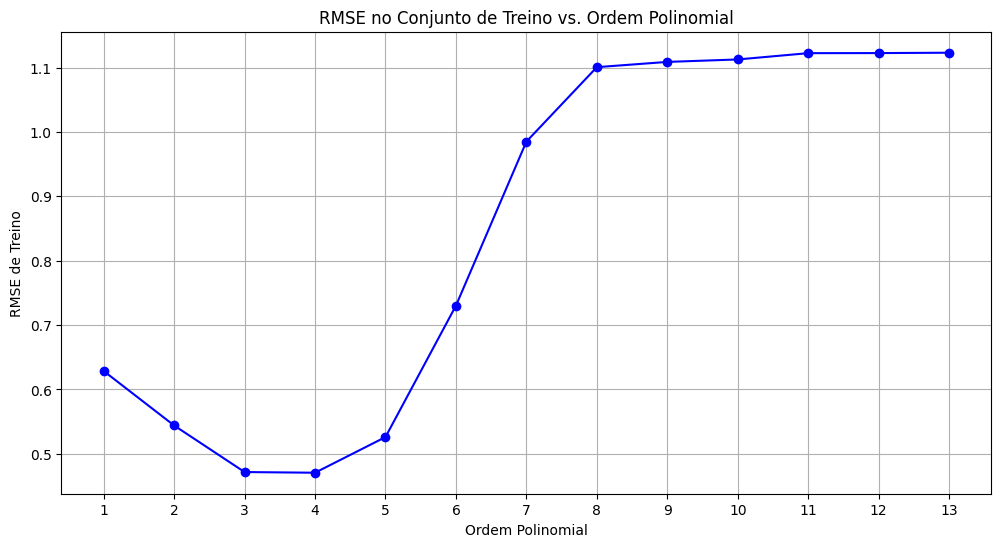

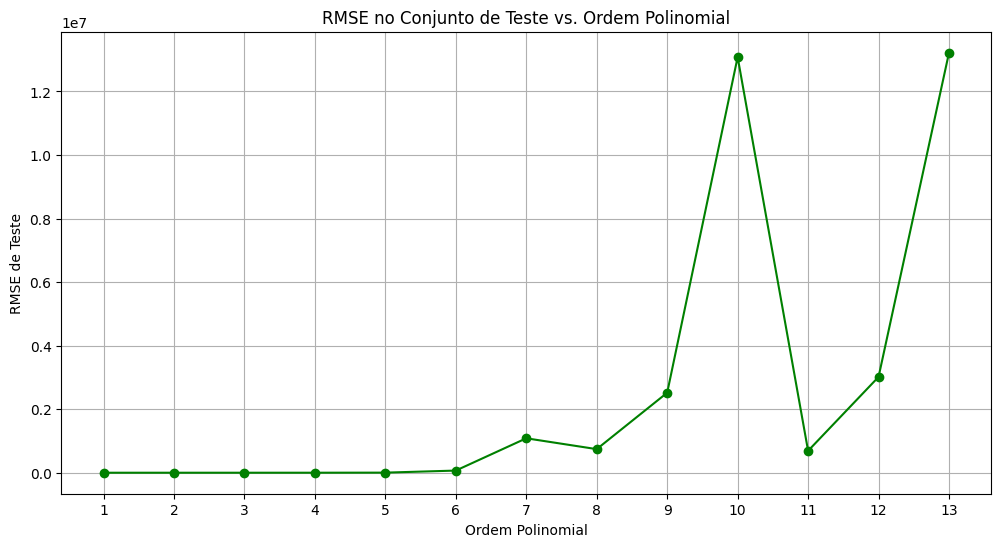

Geração de relatórios de RMSE e gráficos concluída.


In [25]:
from sklearn.metrics import mean_squared_error

# Listas para armazenar os valores de RMSE
rmse_train = []
rmse_test = []
orders = []

# Cálculo do RMSE para cada modelo
for model_info in polynomial_models:
    order = model_info['order']
    poly_transformer = model_info['poly_transformer']
    model = model_info['model']
    orders.append(order)

    # Transformação das features para a ordem polinomial
    X_train_poly = poly_transformer.transform(X_train)
    X_test_poly = poly_transformer.transform(X_test)

    # Previsões
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Cálculo do RMSE para treino
    mse_train_current = mean_squared_error(y_train, y_train_pred)
    rmse_train_current = np.sqrt(mse_train_current)
    rmse_train.append(rmse_train_current)

    # Cálculo do RMSE para teste
    mse_test_current = mean_squared_error(y_test, y_test_pred)
    rmse_test_current = np.sqrt(mse_test_current)
    rmse_test.append(rmse_test_current)

    print(f"Ordem {order}: RMSE de Treino = {rmse_train_current:.4f}, RMSE de Teste = {rmse_test_current:.4f}")

# Gráfico do RMSE (treino)
plt.figure(figsize=(12, 6))
plt.plot(orders, rmse_train, marker='o', linestyle='-', color='blue')
plt.title('RMSE no Conjunto de Treino vs. Ordem Polinomial')
plt.xlabel('Ordem Polinomial')
plt.ylabel('RMSE de Treino')
plt.xticks(orders)
plt.grid(True)
plt.show()

# |Gráfico do RMSE (teste)
plt.figure(figsize=(12, 6))
plt.plot(orders, rmse_test, marker='o', linestyle='-', color='green')
plt.title('RMSE no Conjunto de Teste vs. Ordem Polinomial')
plt.xlabel('Ordem Polinomial')
plt.ylabel('RMSE de Teste')
plt.xticks(orders)
plt.grid(True)
plt.show()

print("Geração de relatórios de RMSE e gráficos concluída.")

###### d) Repita os 2 itens anteriores incluindo um termo de regularização L2 (por exemplo, com fator λ = 0.01).

Ordem 1: RMSE de Treino = 0.6286, RMSE de Teste = 0.8215
Ordem 2: RMSE de Treino = 0.5452, RMSE de Teste = 0.7880
Ordem 3: RMSE de Treino = 0.4656, RMSE de Teste = 12.6519


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.36815e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.48533e-28): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.02588e-36): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Ordem 4: RMSE de Treino = 0.3267, RMSE de Teste = 201.9750


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Ordem 5: RMSE de Treino = 1.0761, RMSE de Teste = 877.8600


...

Ordem 11: RMSE de Treino = 1.1386, RMSE de Teste = 352053.7936


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Ordem 12: RMSE de Treino = 1.1329, RMSE de Teste = 450178.0728


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Ordem 13: RMSE de Treino = 1.1316, RMSE de Teste = 406978.4419


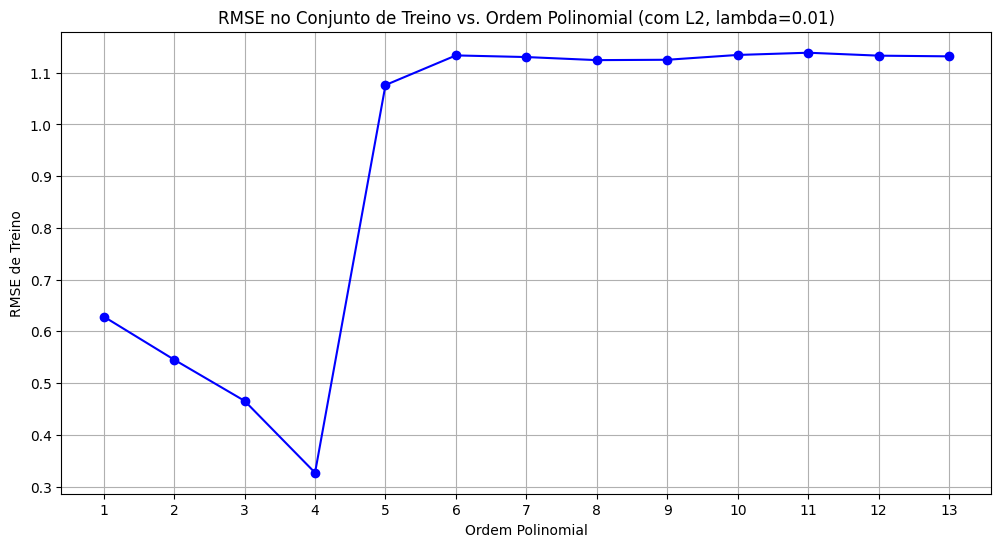

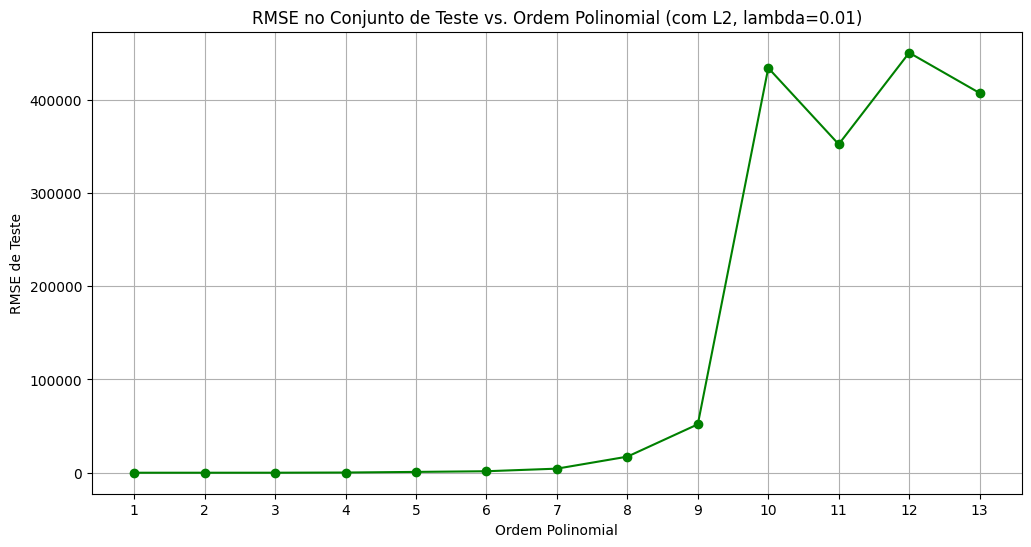

In [26]:
from sklearn.linear_model import Ridge

# Fator de regularização L2
alpha_l2 = 0.01

# Listas para armazenar os modelos e os valores de RMSE
polynomial_models_l2 = []
rmse_train_l2 = []
rmse_test_l2 = []
orders_l2 = []

# Iterando as ordens polinomiais
for order in range(1, 14):
    orders_l2.append(order)

    poly_features = PolynomialFeatures(degree=order, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)

    # 2. Treino do modelo de Regressão Ridge (OLS com regularização L2)
    ridge_reg = Ridge(alpha=alpha_l2, solver='cholesky', random_state=42)  # 'cholesky' costuma ser eficiente para conjuntos de dados menores
    ridge_reg.fit(X_train_poly, y_train)

    # Armazenamento do modelo treinado e o transformador
    polynomial_models_l2.append({
        'order': order,
        'poly_transformer': poly_features,
        'model': ridge_reg
    })

    # Fazer previsões
    y_train_pred = ridge_reg.predict(X_train_poly)
    y_test_pred = ridge_reg.predict(X_test_poly)

    # Cálculo do RMSE(treino)
    mse_train_current = mean_squared_error(y_train, y_train_pred)
    rmse_train_current = np.sqrt(mse_train_current)
    rmse_train_l2.append(rmse_train_current)

    # Cálculo do RMSE(teste)
    mse_test_current = mean_squared_error(y_test, y_test_pred)
    rmse_test_current = np.sqrt(mse_test_current)
    rmse_test_l2.append(rmse_test_current)

    print(f"Ordem {order}: RMSE de Treino = {rmse_train_current:.4f}, RMSE de Teste = {rmse_test_current:.4f}")

# Gráfico do RMSE(treino - L2)
plt.figure(figsize=(12, 6))
plt.plot(orders_l2, rmse_train_l2, marker='o', linestyle='-', color='blue')
plt.title(f'RMSE no Conjunto de Treino vs. Ordem Polinomial (com L2, lambda={alpha_l2})')
plt.xlabel('Ordem Polinomial')
plt.ylabel('RMSE de Treino')
plt.xticks(orders_l2)
plt.grid(True)
plt.show()

# Gráfico do RMSE(teste - L2)
plt.figure(figsize=(12, 6))
plt.plot(orders_l2, rmse_test_l2, marker='o', linestyle='-', color='green')
plt.title(f'RMSE no Conjunto de Teste vs. Ordem Polinomial (com L2, lambda={alpha_l2})')
plt.xlabel('Ordem Polinomial')
plt.ylabel('RMSE de Teste')
plt.xticks(orders_l2)
plt.grid(True)
plt.show()

# Questão 3

##### Considere o conjunto de dados disponível em breastcancer.csv, organizado em 31 colunas, sendo as 30 primeiras colunas os atributos e a última coluna a saída.
##### Os 30 atributos coletados de exames médicos são usados no diagnóstico do câncer de mama, sendo 1 a classe positiva e 0 a classe negativa. Maiores detalhes sobre os dados podem ser conferidos em https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset.



###### a) Considerando uma validação cruzada em 10 folds, avalie um modelo de Regressão Logística (treinado com GD ou SGD) nos dados em questão.

In [27]:
# Separar as features (X) e o alvo (y)
X_breastcancer = ds_breastcancer.iloc[:, :30]  # Features são as colunas de 0 a 29
y_breastcancer = ds_breastcancer.iloc[:, 30]  # O alvo é a última coluna (coluna 30)

# Adicionando um termo de viés
X_breastcancer_biased = np.c_[np.ones(X_breastcancer.shape[0]), X_breastcancer]

# Conversão para um array NumPy
y_breastcancer = y_breastcancer.values

print(f"Forma de X_breastcancer (features): {X_breastcancer.shape}")
print(f"Forma de y_breastcancer (alvo): {y_breastcancer.shape}")
print(f"Forma de X_breastcancer_biased (features com viés): {X_breastcancer_biased.shape}")

Forma de X_breastcancer (features): (568, 30)
Forma de y_breastcancer (alvo): (568,)
Forma de X_breastcancer_biased (features com viés): (568, 31)


In [38]:
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.cost_history = []

    def _sigmoid(self, z):
        # Limitar os valores para evitar overflow na função exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _predict_proba(self, X):
        z = X @ self.theta
        return self._sigmoid(z)

    def predict_classes(self, X):
        # Predição dos rótulos de classe (0 ou 1)
        prob = self._predict_proba(X)
        return (prob >= 0.5).astype(int)

    def _cost_function(self, X, y):
        # Custo de entropia cruzada binária
        m = X.shape[0]
        prob = self._predict_proba(X)

        # Limitar probabilidades para evitar erros de log(0)
        prob = np.clip(prob, 1e-10, 1 - 1e-10)

        cost = (-1/m) * np.sum(
            y * np.log(prob) + (1 - y) * np.log(1 - prob)
        )
        return cost

    def fit(self, X, y):

        # Treinamento do modelo de Regressão Logística usando gradiente descendente
        self.theta = np.zeros(X.shape[1])
        self.cost_history = []

        for iteration in range(self.n_iterations):
            # Cálculo das probabilidades previstas
            prob = self._predict_proba(X)

            # Erro
            errors = prob - y

            # Cálculo do gradiente da função/custo
            gradients = (1/X.shape[0]) * X.T @ errors

            # Atualização dos pesos
            self.theta = self.theta - self.learning_rate * gradients

            # Custo para a curva de aprendizagem
            cost = self._cost_function(X, y)
            self.cost_history.append(cost)

        print(
            f"Modelo de Regressão Logística treinado com {self.n_iterations} iterações. "
            f"Custo Final: {self.cost_history[-1]:.4f}"
        )

In [31]:
# Validação cruzada em 10 folds

def k_fold_split(X, y, n_splits=10, random_state=42):
    np.random.seed(random_state)
    m = X.shape[0]
    indices = np.arange(m)
    np.random.shuffle(indices)

    fold_sizes = np.full(n_splits, m // n_splits, dtype=int)
    fold_sizes[:m % n_splits] += 1

    current = 0
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        test_indices = indices[start:stop]
        train_indices = np.concatenate([indices[:start], indices[stop:]])
        yield train_indices, test_indices
        current = stop

In [34]:
# Funções de Cálculo das acurácias

def calculate_accuracy(y_true, y_pred):
    # Cálculo da acurácia global
    return np.mean(y_true == y_pred)

def calculate_accuracy_per_class(y_true, y_pred, class_labels=[0, 1]):
    # Cálculo da acurácia para cada classe
    accuracies_per_class = {}
    for cls in class_labels:
        class_indices = (y_true == cls)
        if np.sum(class_indices) > 0:
            # Comparação dos rótulos previstos para a classe
            accuracies_per_class[cls] = np.mean(
                y_true[class_indices] == y_pred[class_indices]
            )
        else:
            accuracies_per_class[cls] = np.nan
    return accuracies_per_class

In [37]:
# Parâmetros para Regressão Logística
learning_rate_lr = 0.1
n_iterations_lr = 5000
n_folds = 10

# Listas para armazenar as métricas de cada fold
global_accuracies = []
class_0_accuracies = []
class_1_accuracies = []

print(f"Iniciando Validação Cruzada {n_folds}-Fold para Regressão Logística...")

# Executar validação cruzada k-fold
for fold, (train_indices, test_indices) in enumerate(
    k_fold_split(X_breastcancer_biased, y_breastcancer, n_splits=n_folds)
):
    print(f"\n--- Fold {fold + 1}/{n_folds} ---")

    # Dividir os dados para o fold atual
    X_train_fold, X_test_fold = (
        X_breastcancer_biased[train_indices],
        X_breastcancer_biased[test_indices]
    )
    y_train_fold, y_test_fold = (
        y_breastcancer[train_indices],
        y_breastcancer[test_indices]
    )

    # Inicializar e treinar o modelo de Regressão Logística
    model = LogisticRegressionGD(
        learning_rate=learning_rate_lr,
        n_iterations=n_iterations_lr
    )
    model.fit(X_train_fold, y_train_fold)

    # Fazer previsões no conjunto de teste
    y_pred_fold = model.predict_classes(X_test_fold)

    # Cálculo da acurácia global
    current_global_accuracy = calculate_accuracy(y_test_fold, y_pred_fold)
    global_accuracies.append(current_global_accuracy)
    print(f"Acurácia Global: {current_global_accuracy:.4f}")

    # Cálculo a acurácia por classe
    current_class_accuracies = calculate_accuracy_per_class(
        y_test_fold, y_pred_fold, class_labels=[0, 1]
    )
    if 0 in current_class_accuracies and not np.isnan(current_class_accuracies[0]):
        class_0_accuracies.append(current_class_accuracies[0])
        print(f"Acurácia Classe 0: {current_class_accuracies[0]:.4f}")
    if 1 in current_class_accuracies and not np.isnan(current_class_accuracies[1]):
        class_1_accuracies.append(current_class_accuracies[1])
        print(f"Acurácia Classe 1: {current_class_accuracies[1]:.4f}")

Iniciando Validação Cruzada 10-Fold para Regressão Logística...

--- Fold 1/10 ---
Modelo de Regressão Logística treinado com 5000 iterações. Custo Final: 3.1711
Acurácia Global: 0.8070
Acurácia Classe 0: 0.7105
Acurácia Classe 1: 1.0000

--- Fold 2/10 ---
Modelo de Regressão Logística treinado com 5000 iterações. Custo Final: 1.8024
Acurácia Global: 0.8596
Acurácia Classe 0: 0.9333
Acurácia Classe 1: 0.7778

--- Fold 3/10 ---
Modelo de Regressão Logística treinado com 5000 iterações. Custo Final: 2.0277
Acurácia Global: 0.8947
Acurácia Classe 0: 1.0000
Acurácia Classe 1: 0.7273

--- Fold 4/10 ---
Modelo de Regressão Logística treinado com 5000 iterações. Custo Final: 2.3776
Acurácia Global: 0.9298
Acurácia Classe 0: 1.0000
Acurácia Classe 1: 0.8182

--- Fold 5/10 ---
Modelo de Regressão Logística treinado com 5000 iterações. Custo Final: 2.1629
Acurácia Global: 0.8246
Acurácia Classe 0: 0.8095
Acurácia Classe 1: 0.8667

--- Fold 6/10 ---
Modelo de Regressão Logística treinado com 5000

###### b) Reporte valor médio e desvio padrão da acurácia global e da acurácia por classe.

In [36]:
# Cálculo da média e do desvio padrão da acurácia global
mean_global_accuracy = np.mean(global_accuracies)
std_global_accuracy = np.std(global_accuracies)

# Cálculo da média e do desvio padrão da acurácia da classe 0
mean_class_0_accuracy = np.mean(class_0_accuracies)
std_class_0_accuracy = np.std(class_0_accuracies)

# Cálculo da média e do desvio padrão da acurácia da classe 1
mean_class_1_accuracy = np.mean(class_1_accuracies)
std_class_1_accuracy = np.std(class_1_accuracies)

print("\n--- Resultados da Validação Cruzada ---")
print(f"Acurácia Global: Média = {mean_global_accuracy:.4f}, Desvio Padrão = {std_global_accuracy:.4f}")
print(f"Acurácia Classe 0: Média = {mean_class_0_accuracy:.4f}, Desvio Padrão = {std_class_0_accuracy:.4f}")
print(f"Acurácia Classe 1: Média = {mean_class_1_accuracy:.4f}, Desvio Padrão = {std_class_1_accuracy:.4f}")



--- Resultados da Validação Cruzada ---
Acurácia Global: Média = 0.8716, Desvio Padrão = 0.0399
Acurácia Classe 0: Média = 0.9284, Desvio Padrão = 0.0919
Acurácia Classe 1: Média = 0.7882, Desvio Padrão = 0.1125


# Questão 4

##### Considere o conjunto de dados disponível em vehicle.csv, organizado em 19 colunas, sendo as 18 primeiras colunas os atributos e a última coluna a saída.

##### Os 18atributos caracterizam a silhueta de veículos, extraídos pelo método HIPS (Hierarchical Image Processing System). A tarefa consiste em classificar o veículo em 4 classes (bus, opel, saab, e van). Maiores detalhes sobre os dados podem ser conferidos em https://www.openml.org/search?type=data&sort=runs&id=54.



###### a) Considerando uma validação cruzada em 10 folds, avalie um modelo de Regressão Softmax (treinado com GD ou SGD) nos dados em questão.

In [40]:
# Separar as features (X) e o alvo (y)
X_vehicle = ds_vehicle.iloc[:, :18]
y_vehicle = ds_vehicle.iloc[:, 18]

# Obter os rótulos categóricos únicos e criar um mapeamento para inteiros
unique_labels = y_vehicle.unique()
label_to_int = {label: i for i, label in enumerate(unique_labels)}

# Mapeamento em y_vehicle
y_vehicle_encoded = np.array([label_to_int[label] for label in y_vehicle])

# Codificação one-hot em y_vehicle_encoded
num_classes = len(unique_labels)
y_vehicle_one_hot = np.eye(num_classes)[y_vehicle_encoded]

# Coluna de uns como termo de viés em X_vehicle
X_vehicle_biased = np.c_[np.ones(X_vehicle.shape[0]), X_vehicle]

print(f"Forma de X_vehicle original (features): {X_vehicle.shape}")
print(f"Forma de y_vehicle original (alvo): {y_vehicle.shape}")
print(f"Rótulos únicos encontrados: {unique_labels}")
print(f"Forma de y_vehicle_encoded (rótulos inteiros): {y_vehicle_encoded.shape}")
print(f"Forma de y_vehicle_one_hot (alvo codificado em one-hot): {y_vehicle_one_hot.shape}")
print(f"Forma de X_vehicle_biased (features com viés): {X_vehicle_biased.shape}")
print("Preparação dos dados para vehicle.csv concluída.")


Forma de X_vehicle original (features): (845, 18)
Forma de y_vehicle original (alvo): (845,)
Rótulos únicos encontrados: [3. 2. 0. 1.]
Forma de y_vehicle_encoded (rótulos inteiros): (845,)
Forma de y_vehicle_one_hot (alvo codificado em one-hot): (845, 4)
Forma de X_vehicle_biased (features com viés): (845, 19)
Preparação dos dados para vehicle.csv concluída.


In [42]:
class SoftmaxRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000, random_state=42):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.cost_history = []
        np.random.seed(random_state)

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _predict_proba(self, X):
        logits = X @ self.theta
        return self._softmax(logits)

    def predict_classes(self, X):
        # Predição dos rótulos das classes
        probabilities = self._predict_proba(X)
        return np.argmax(probabilities, axis=1)

    def _cost_function(self, X, y_one_hot):
        # Custo de entropia cruzada multiclasse
        m = X.shape[0]
        probabilities = self._predict_proba(X)

        # Limitar probabilidades para evitar erros de log(0)
        probabilities = np.clip(probabilities, 1e-10, 1 - 1e-10)

        # Perda de entropia cruzada multiclasse
        cost = -np.sum(y_one_hot * np.log(probabilities)) / m
        return cost

    def fit(self, X, y_one_hot):

        n_features = X.shape[1]
        n_classes = y_one_hot.shape[1]

        # Inicializar theta (pesos) com pequenos valores aleatórios
        self.theta = np.random.randn(n_features, n_classes) * 0.01
        self.cost_history = []

        for iteration in range(self.n_iterations):
            # Cálculo das probabilidades previstas para todas as classes
            prob = self._predict_proba(X)

            # Cálculo do erro (probabilidades - rótulos verdadeiros em one-hot)
            errors = prob - y_one_hot

            # Cálculo do gradiente da função de custo
            gradients = (1/X.shape[0]) * X.T @ errors

            # Atualizar os pesos (theta)
            self.theta = self.theta - self.learning_rate * gradients

            # Registrar o custo para a curva de aprendizagem
            cost = self._cost_function(X, y_one_hot)
            self.cost_history.append(cost)

        print(
            f"Modelo de Regressão Softmax treinado com {self.n_iterations} iterações. "
            f"Custo Final: {self.cost_history[-1]:.4f}"
        )

In [43]:
# Funções de cálculo de acurácia

def calculate_accuracy(y_true, y_pred):
    # Cálculo da acurácia global
    return np.mean(y_true == y_pred)

def calculate_accuracy_per_class(y_true, y_pred):
    # Cálcula da acurácia
    accuracies_per_class = {}
    # Rótulos de classe únicos(rótulos verdadeiros)
    class_labels = np.unique(y_true)

    for cls in class_labels:
        class_indices = (y_true == cls)
        if np.sum(class_indices) > 0:
            # Cálculo da acurácia (classe específica)
            accuracies_per_class[cls] = np.mean(
                y_true[class_indices] == y_pred[class_indices]
            )
        else:
            accuracies_per_class[cls] = np.nan
    return accuracies_per_class

In [45]:
# Parâmetros para Regressão Softmax
learning_rate_sr = 0.1
n_iterations_sr = 5000
n_folds_sr = 10

# Listas para armazenar as métricas de cada fold
global_accuracies_sr = []
class_accuracies_by_fold = []

# Validação cruzada k-fold
for fold, (train_indices, test_indices) in enumerate(
    k_fold_split(X_vehicle_biased, y_vehicle_encoded, n_splits=n_folds_sr)
):
    print(f"\n--- Fold {fold + 1}/{n_folds_sr} ---")

    # Divisão dos dados para o fold atual
    X_train_fold, X_test_fold = X_vehicle_biased[train_indices], X_vehicle_biased[test_indices]
    y_train_encoded_fold, y_test_encoded_fold = (
        y_vehicle_encoded[train_indices],
        y_vehicle_encoded[test_indices],
    )

    # Rótulos
    y_train_one_hot_fold = y_vehicle_one_hot[train_indices]

    # Início de treino do modelo de Regressão Softmax
    model_sr = SoftmaxRegressionGD(
        learning_rate=learning_rate_sr,
        n_iterations=n_iterations_sr
    )
    model_sr.fit(X_train_fold, y_train_one_hot_fold)

    # Predições no conjunto de teste
    y_pred_encoded_fold = model_sr.predict_classes(X_test_fold)

    # Cálculo da acurácia global
    current_global_accuracy_sr = calculate_accuracy(
        y_test_encoded_fold,
        y_pred_encoded_fold
    )
    global_accuracies_sr.append(current_global_accuracy_sr)
    print(f"Acurácia Global: {current_global_accuracy_sr:.4f}")

    # Cálculo da acurácia por classe
    current_class_accuracies_sr = calculate_accuracy_per_class(
        y_test_encoded_fold,
        y_pred_encoded_fold
    )
    class_accuracies_by_fold.append(current_class_accuracies_sr)
    for cls, acc in current_class_accuracies_sr.items():
        print(f"Acurácia Classe {cls}: {acc:.4f}")


# Média e Desvio Padrão da acurácia global
mean_global_accuracy_sr = np.mean(global_accuracies_sr)
std_global_accuracy_sr = np.std(global_accuracies_sr)

# Média e Desvio padrão da acurácia por classe ao longo dos folds
# Isso requer reunir todas as acurácias de cada classe primeiro
all_class_accuracies = {cls: [] for cls in unique_labels}

for fold_accuracies in class_accuracies_by_fold:
    for cls, acc in fold_accuracies.items():
        if not np.isnan(acc):
            all_class_accuracies[cls].append(acc)

mean_class_accuracies_sr = {
    cls: np.mean(accs) for cls, accs in all_class_accuracies.items() if accs
}
std_class_accuracies_sr = {
    cls: np.std(accs) for cls, accs in all_class_accuracies.items() if accs
}

print("\n--- Resultados da Validação Cruzada da Regressão Softmax ---")
print(f"Acurácia Global: Média = {mean_global_accuracy_sr:.4f}, Desvio Padrão = {std_global_accuracy_sr:.4f}")
for cls in sorted(mean_class_accuracies_sr.keys()):
    print(
        f"Acurácia Classe {cls}: "
        f"Média = {mean_class_accuracies_sr[cls]:.4f}, "
        f"Desvio Padrão = {std_class_accuracies_sr[cls]:.4f}"
    )



--- Fold 1/10 ---
Modelo de Regressão Softmax treinado com 5000 iterações. Custo Final: 12.0280
Acurácia Global: 0.4353
Acurácia Classe 0: 1.0000
Acurácia Classe 1: 0.0000
Acurácia Classe 2: 1.0000
Acurácia Classe 3: 0.0000

--- Fold 2/10 ---
Modelo de Regressão Softmax treinado com 5000 iterações. Custo Final: 11.7553
Acurácia Global: 0.5529
Acurácia Classe 0: 0.9630
Acurácia Classe 1: 0.0000
Acurácia Classe 2: 0.9524
Acurácia Classe 3: 0.0588

--- Fold 3/10 ---
Modelo de Regressão Softmax treinado com 5000 iterações. Custo Final: 8.6953
Acurácia Global: 0.6235
Acurácia Classe 0: 1.0000
Acurácia Classe 1: 0.0000
Acurácia Classe 2: 0.7727
Acurácia Classe 3: 0.8462

--- Fold 4/10 ---
Modelo de Regressão Softmax treinado com 5000 iterações. Custo Final: 13.3440
Acurácia Global: 0.4471
Acurácia Classe 0: 0.6071
Acurácia Classe 1: 0.0526
Acurácia Classe 2: 0.1176
Acurácia Classe 3: 0.8571

--- Fold 5/10 ---
Modelo de Regressão Softmax treinado com 5000 iterações. Custo Final: 14.0774
Acur

###### b) Reporte valor médio e desvio padrão da acurácia global e da acurácia por classe.

In [47]:
# Calcula a média e o desvio padrão da acurácia global
mean_global_accuracy_sr = np.mean(global_accuracies_sr)
std_global_accuracy_sr = np.std(global_accuracies_sr)

# Calcula a média e o desvio padrão da acurácia por classe ao longo dos folds
# Isso requer reunir primeiro todas as acurácias de cada classe
all_class_accuracies = {cls: [] for cls in unique_labels}  # Usa os rótulos originais

for fold_accuracies in class_accuracies_by_fold:
    for cls, acc in fold_accuracies.items():
        if not np.isnan(acc):  # Inclui apenas se a classe esteve presente no fold
            all_class_accuracies[cls].append(acc)

mean_class_accuracies_sr = {
    cls: np.mean(accs) for cls, accs in all_class_accuracies.items() if accs
}
std_class_accuracies_sr = {
    cls: np.std(accs) for cls, accs in all_class_accuracies.items() if accs
}

print("\n--- Resultados da Validação Cruzada da Regressão Softmax ---")
print(
    f"Acurácia Global: Média = {mean_global_accuracy_sr:.4f}, "
    f"Desvio Padrão = {std_global_accuracy_sr:.4f}"
)

for cls in sorted(mean_class_accuracies_sr.keys()):
    print(
        f"Acurácia Classe {cls}: "
        f"Média = {mean_class_accuracies_sr[cls]:.4f}, "
        f"Desvio Padrão = {std_class_accuracies_sr[cls]:.4f}"
    )



--- Resultados da Validação Cruzada da Regressão Softmax ---
Acurácia Global: Média = 0.4995, Desvio Padrão = 0.0798
Acurácia Classe 0.0: Média = 0.7944, Desvio Padrão = 0.2553
Acurácia Classe 1.0: Média = 0.1399, Desvio Padrão = 0.2837
Acurácia Classe 2.0: Média = 0.6438, Desvio Padrão = 0.3461
Acurácia Classe 3.0: Média = 0.4325, Desvio Padrão = 0.4111
